In [1]:
!wget -O Housing.csv https://raw.githubusercontent.com/Turbonik/AILab1/main/Housing.csv

--2026-10-03 06:09:38--  https://raw.githubusercontent.com/Turbonik/AILab1/main/Housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29981 (29K) [text/plain]
Saving to: ‘Housing.csv’

Housing.csv         100%[===================>]  29.28K  --.-KB/s    in 0s      

2026-10-03 06:09:38 (195 MB/s) - ‘Housing.csv’ saved [29981/29981]



ПУАССОНОВСКАЯ РЕГРЕССИЯ

Статистика модели
  Псевдо-R2 (McFadden)           0.4500
  LogLik модели         -101550669.3982
  LogLik нулевой        -184625562.3157
  LR-статистика          166149785.8350
  df                                  3
  p-значение (Хи2)         0.000000e+00
  Хи2/df Пирсона           3.962731e+05
  Наблюдения                        545

                       Коэф.    Ст.ошибка    z-Вальд       p-знач.       IRR     95% нижн.     95% верх.
--------------------------------------------------------------------------------------------------------------
Пересечение        14.872348     0.000050  294804.10      0.00e+002877258.2402       14.8722       14.8724
area                0.000068     0.000000    7918.26      0.00e+00    1.0001        0.0001        0.0001
prefarea            0.162266     0.000045    3625.84      0.00e+00    1.1762        0.1622        0.1624
airconditioning     0.273922     0.000041    6674.65      0.00e+00    1.3151        0.2738        0.274

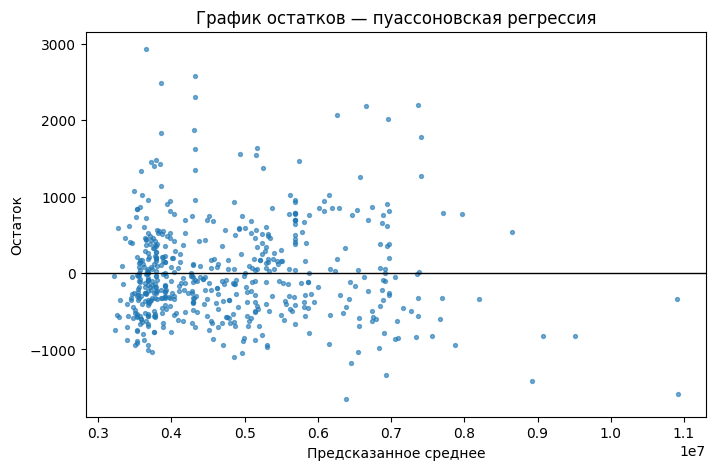

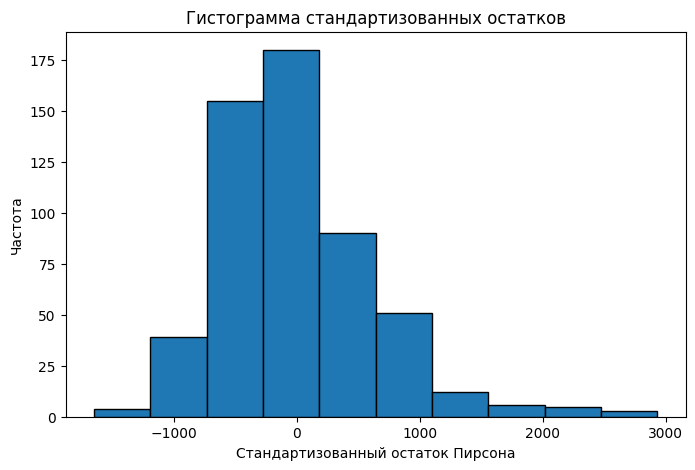

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import glm
from statsmodels.genmod.families import Poisson
from scipy.stats import chi2, norm

df = pd.read_csv("Housing.csv")

df["prefarea"]        = df["prefarea"].astype(str).str.lower().str.strip().isin(["да","yes","1"]).astype(int)
df["airconditioning"] = df["airconditioning"].astype(str).str.lower().str.strip().isin(["да","yes","1"]).astype(int)

m = glm("price ~ area + prefarea + airconditioning", data=df, family=Poisson()).fit()

names = ["Пересечение", "area", "prefarea", "airconditioning"]
b     = m.params
se    = m.bse
z     = m.tvalues
p     = m.pvalues
irr   = np.exp(b)
ci_lo = b - norm.ppf(0.975) * se
ci_hi = b + norm.ppf(0.975) * se

ll     = m.llf
ll0    = m.llnull
lr     = 2 * (ll - ll0)
df_lr  = int(m.df_model)
p_lr   = chi2.sf(lr, df_lr)
pseudo = 1 - ll / ll0

print("ПУАССОНОВСКАЯ РЕГРЕССИЯ")
print()
print("Статистика модели")
print(f"  Псевдо-R2 (McFadden)  {pseudo:>15.4f}")
print(f"  LogLik модели         {ll:>15.4f}")
print(f"  LogLik нулевой        {ll0:>15.4f}")
print(f"  LR-статистика         {lr:>15.4f}")
print(f"  df                    {df_lr:>15d}")
print(f"  p-значение (Хи2)      {p_lr:>15.6e}")
print(f"  Хи2/df Пирсона        {m.pearson_chi2/m.df_resid:>15.6e}")
print(f"  Наблюдения            {int(m.nobs):>15d}")
print()
print(f"{'':<15}{'Коэф.':>13}{'Ст.ошибка':>13}{'z-Вальд':>11}{'p-знач.':>14}{'IRR':>10}{'95% нижн.':>14}{'95% верх.':>14}")
print("-" * 110)
for i, nm in enumerate(names):
    print(f"{nm:<15}{b.iloc[i]:>13.6f}{se.iloc[i]:>13.6f}{z.iloc[i]:>11.2f}{p.iloc[i]:>14.2e}{irr.iloc[i]:>10.4f}{ci_lo.iloc[i]:>14.4f}{ci_hi.iloc[i]:>14.4f}")

mu          = m.fittedvalues
h           = m.get_influence().hat_matrix_diag
raw         = df["price"] - mu
pearson     = raw / np.sqrt(mu)
pearson_std = pearson / np.sqrt(1 - h)

print()
print("Таблица остатков — первые 10 строк")
tab = pd.DataFrame({
    "price":         df["price"],
    "Прогноз":       mu,
    "Остаток":       raw,
    "Ост.Пирсона":   pearson,
    "Станд.ост.":    pearson_std,
})
print(tab.head(10).to_string(index=False))

plt.figure(figsize=(8,5))
plt.scatter(mu, pearson_std, s=8, alpha=0.6)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Предсказанное среднее")
plt.ylabel("Остаток")
plt.title("График остатков — пуассоновская регрессия")
plt.show()

k = int(1 + np.log2(len(pearson_std)))
plt.figure(figsize=(8,5))
plt.hist(pearson_std, bins=k, edgecolor="black")
plt.xlabel("Стандартизованный остаток Пирсона")
plt.ylabel("Частота")
plt.title("Гистограмма стандартизованных остатков")
plt.show()